<a href="https://colab.research.google.com/github/Project-EthanG/SSC-Glider-Project/blob/main/Models_Visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# Installs (only needed on first run)
!pip install ripser
!pip install persim
!pip install networkx
!pip install scikit-learn
!pip install matplotlib
!pip install tables



# Package imports (needed every run)
import numpy as np
import math
import pandas as pd
import random
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
from scipy.spatial.distance import pdist, squareform
import networkx as nx
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
import os # Required to use file paths
import shutil # Required to move temporary files around
import random # Used to create training/testing split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import ElasticNet
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import KFold
random.seed(30)
np.random.seed(30)

# As needed
from google.colab import drive
drive.mount('/content/drive')


# Tell python which folder to look in. Change depending on the bin dimension
dim_bins = 100

relative_path = f"/dim_bins{dim_bins}/"

# Function to the h5 file at the chosen path
def read_h5(file_path):
    if file_path.endswith(".h5"):
      df = pd.read_hdf(file_path)
      print("File successfully read.\n")
      return df
    else:
      print("File is not an h5. Skipping...\n")

folder_path = f"/content/drive/MyDrive/Glider data/dim_bins50"

file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
print(file_names)
def split_files(file_names, num_training):
    # Randomly select 'num_in_list1' files
    training_split = random.sample(file_names, num_training)
    # The remaining files
    testing_split = [f for f in file_names if f not in training_split]
    return training_split, testing_split
print(len(file_names))
testing_amount = 16
num_training = len(file_names) - testing_amount
print(num_training)  # 12 testing files, rest for training + eval
training_split, testing_split = split_files(file_names, num_training)

print("Training Split:", training_split)
print("Testing Split:", testing_split)

training_datasets = [pd.read_hdf(os.path.join(folder_path, f), key="data") for f in training_split]
testing_datasets = [pd.read_hdf(os.path.join(folder_path, f), key="data") for f in testing_split]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['component_0_binned_8752.h5', 'component_4_binned_5289.h5', 'component_2_binned_6014.h5', 'component_3_binned_7318.h5', 'component_1_binned_12968.h5', 'component_7_binned_8147.h5', 'component_5_binned_10452.h5', 'component_6_binned_13296.h5', 'component_8_binned_6388.h5', 'component_9_binned_11350.h5', 'component_10_binned_8592.h5', 'component_11_binned_6741.h5', 'component_12_binned_6936.h5', 'component_15_binned_10159.h5', 'component_14_binned_8427.h5', 'component_13_binned_8869.h5', 'component_17_binned_6341.h5', 'component_16_binned_7076.h5', 'component_18_binned_5127.h5', 'component_19_binned_5641.h5', 'component_20_binned_12556.h5', 'component_21_binned_10418.h5', 'component_25_binned_4878.h5', 'component_24_binned_7926.h5', 'component_22_binned_6090.h5', 'component_23_binned_6397.h5', 'component_26_binned_5265.h5', 'component_28_binned_6517.h5', 'comp

Created 252 custom CV splits (5 train folds, 5 evaluation folds per split).


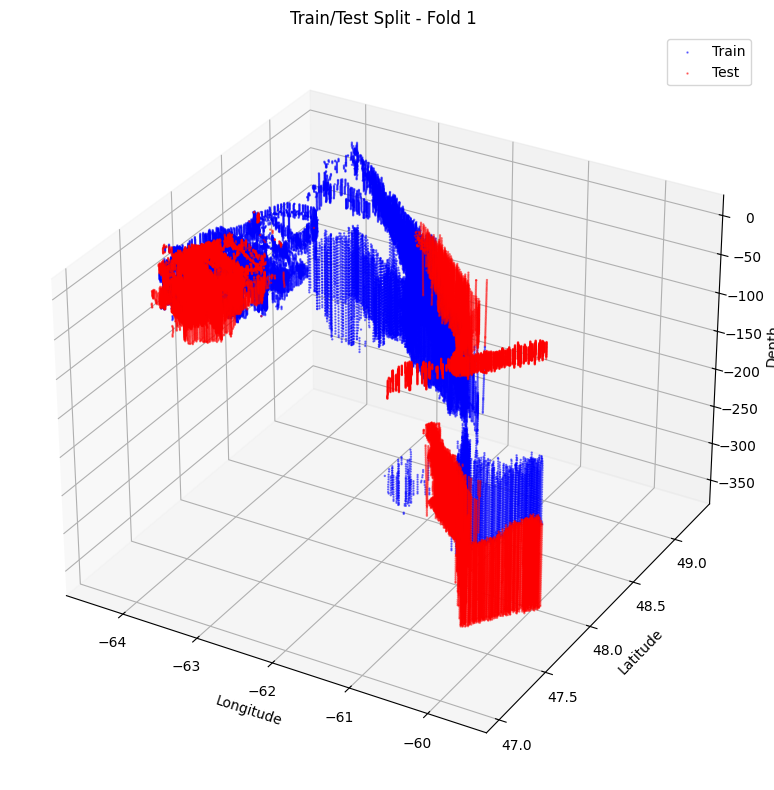

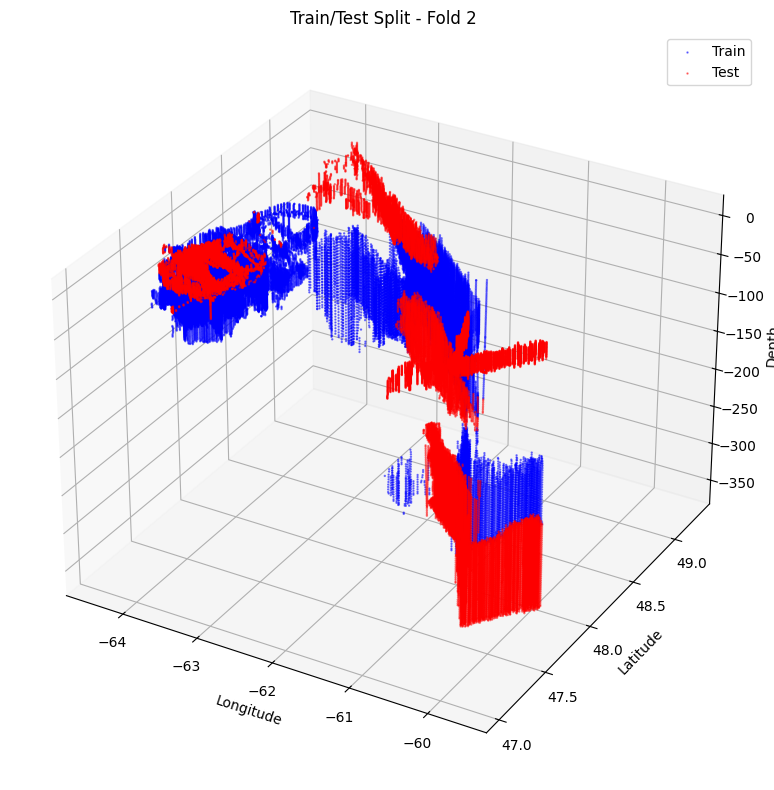

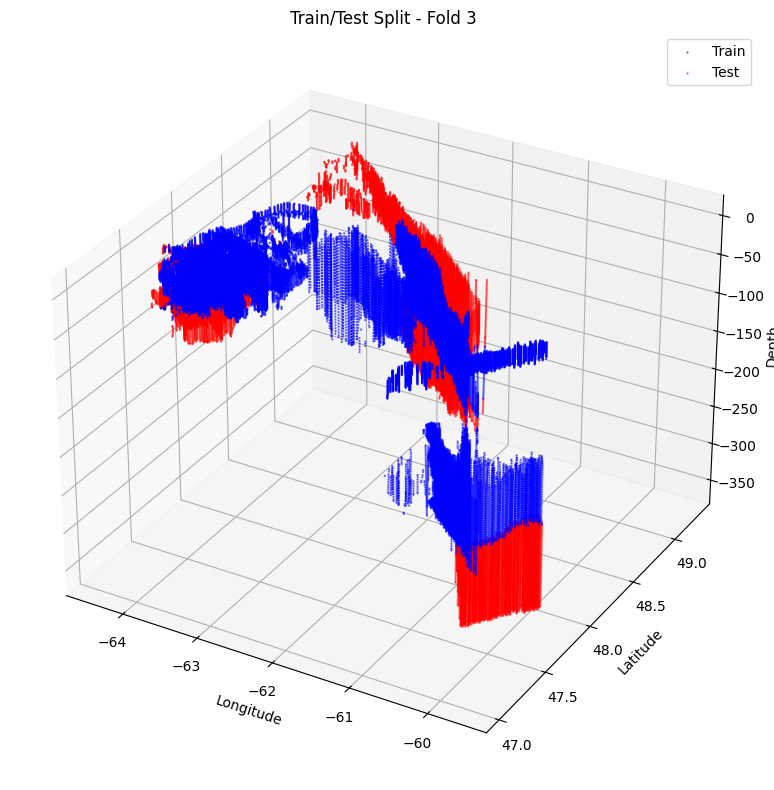

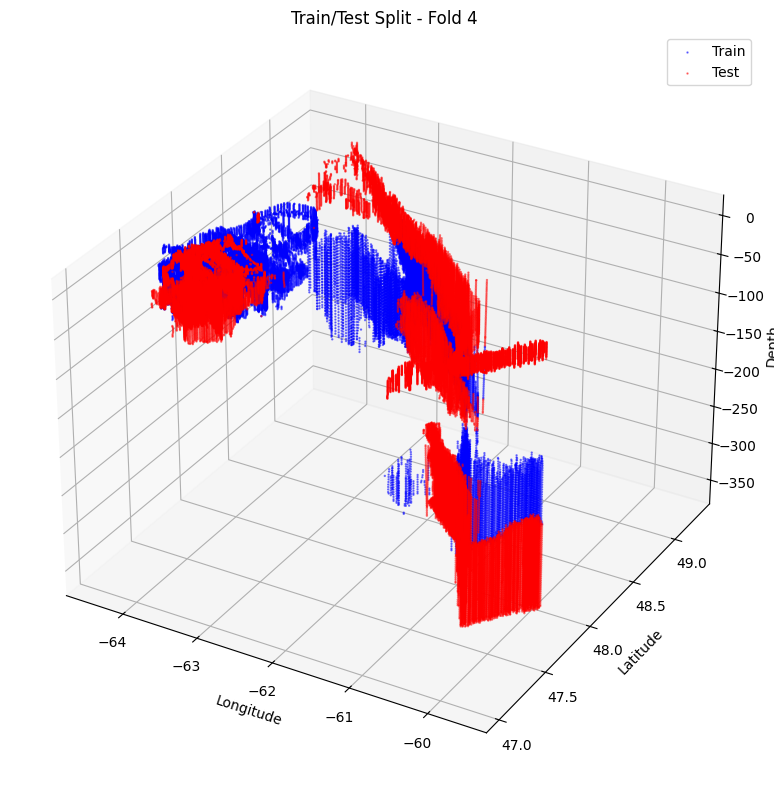

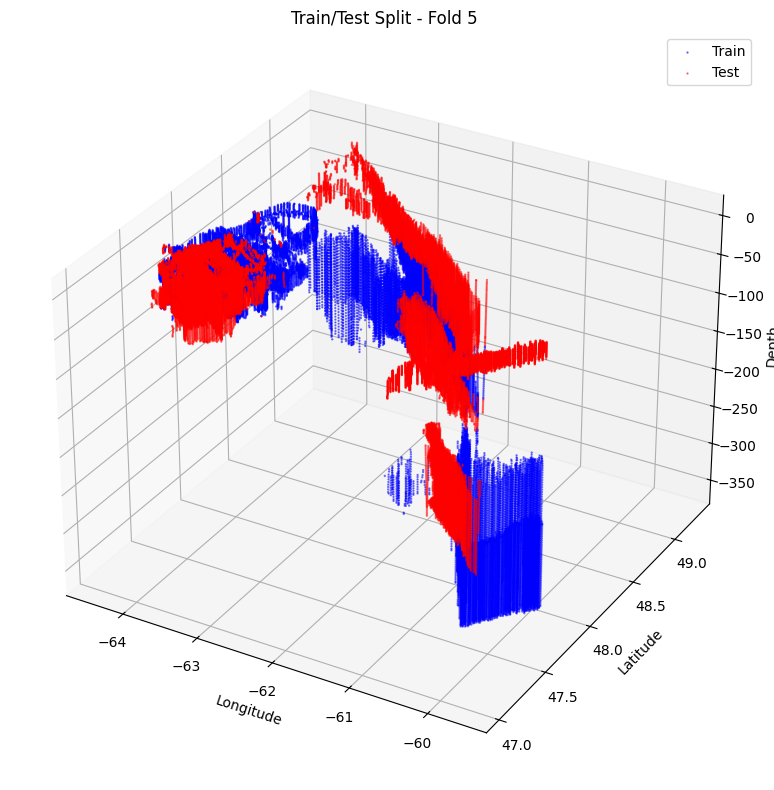

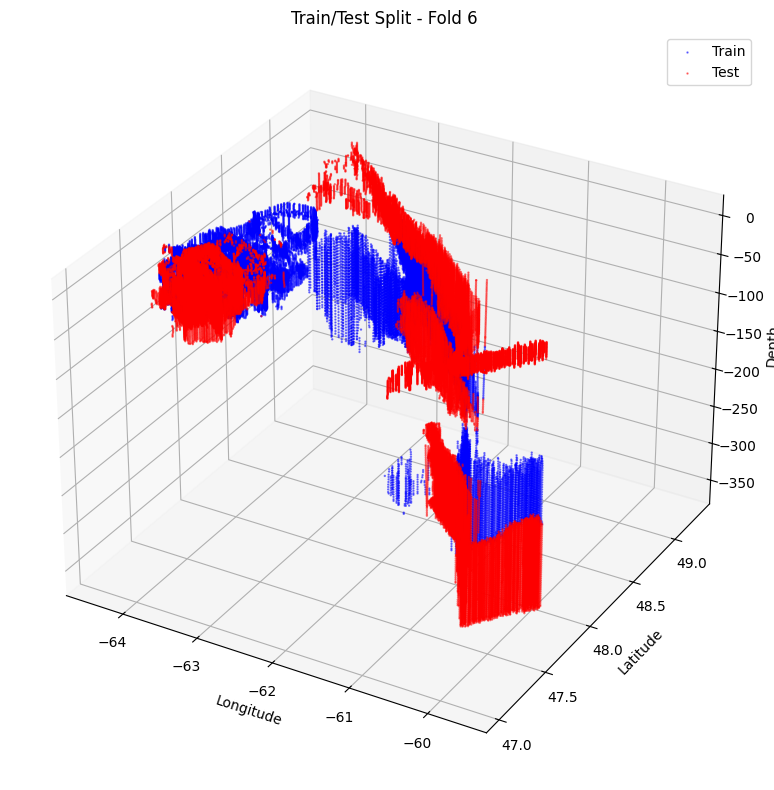

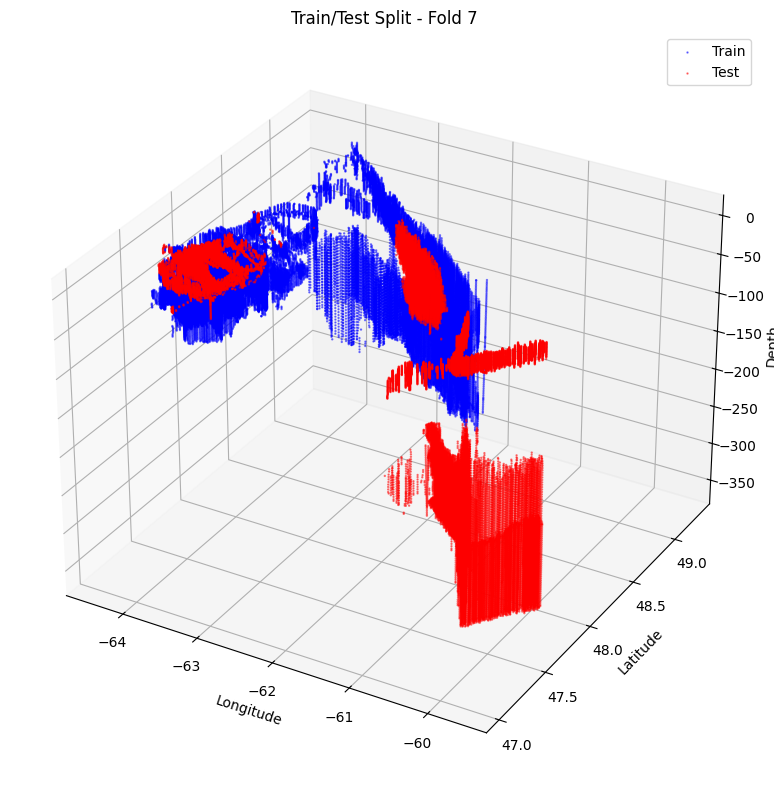

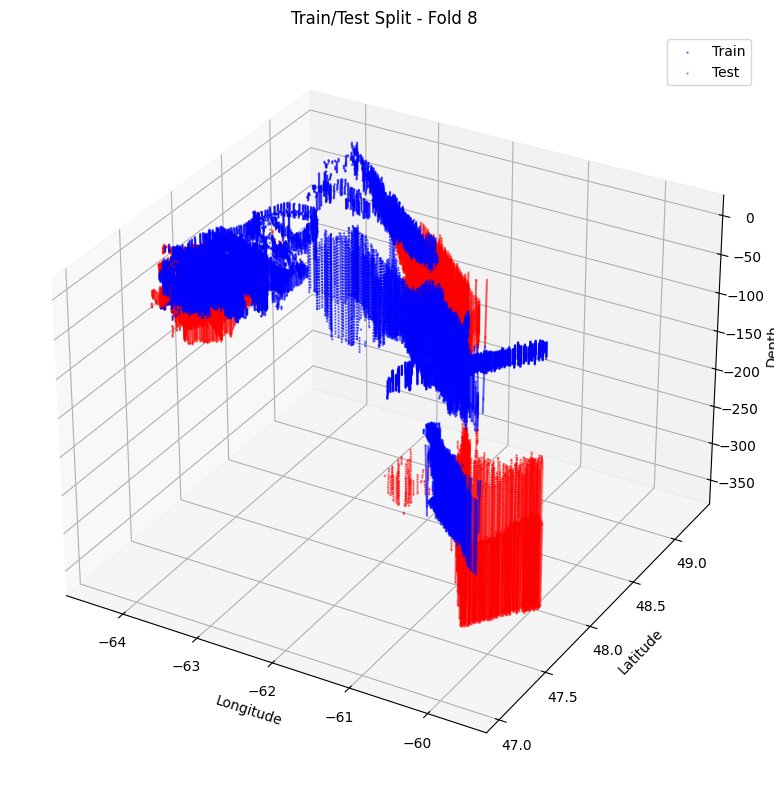

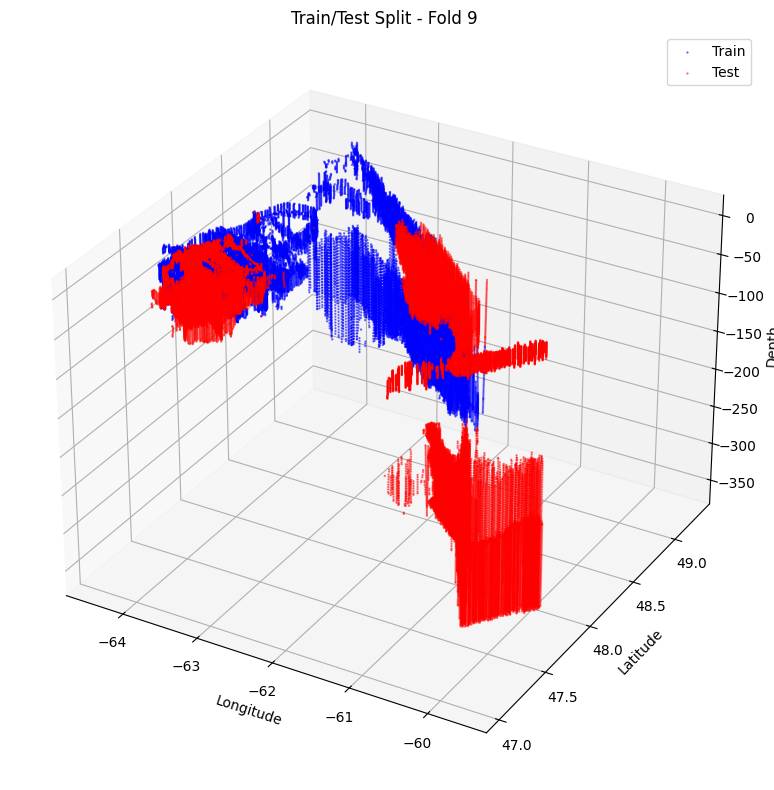

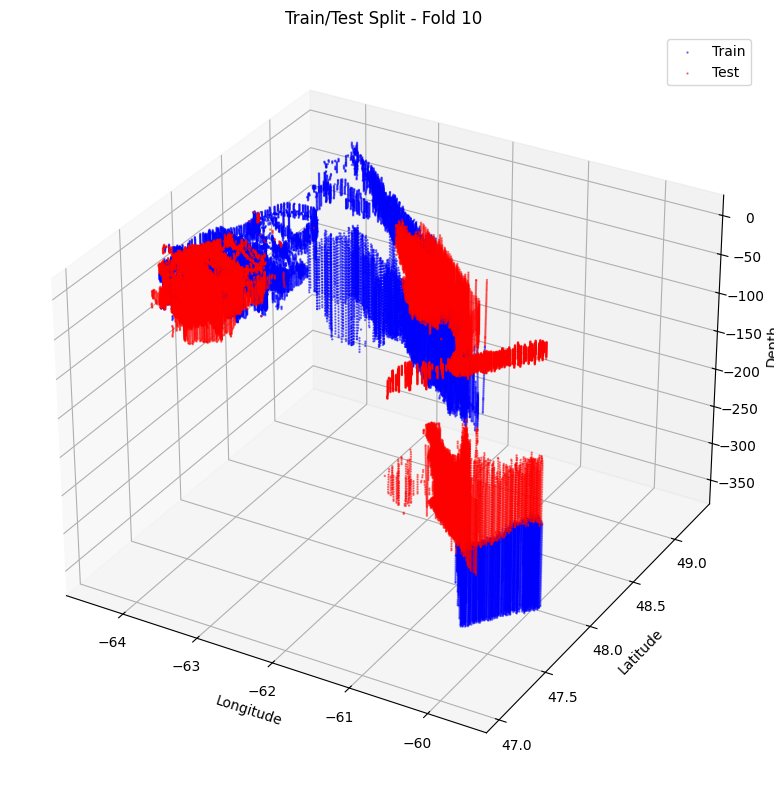

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from itertools import combinations

# Assume datasets is a list of preloaded DataFrames
n_datasets = len(training_datasets)
k = 10 # Total number of folds
train_folds_count = 5

# Step 1: Assign datasets to k folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)
dataset_indices = np.arange(n_datasets)

# Organize dataset indices into k folds
folds = [[] for _ in range(k)]
for fold_idx, (_, test_idx) in enumerate(kf.split(dataset_indices)):
    for i in test_idx:
        folds[fold_idx].append(i)

# Step 2: Generate all combinations of 4 folds for training
train_fold_combos = list(combinations(range(k), train_folds_count))
custom_folds = []

# Step 3: Build train/test sets for each combination
for train_combo in train_fold_combos:
    test_combo = [i for i in range(k) if i not in train_combo]

    train_indices = [idx for fold in train_combo for idx in folds[fold]]
    test_indices = [idx for fold in test_combo for idx in folds[fold]]

    train_df = pd.concat([training_datasets[i] for i in train_indices], ignore_index=True)
    test_df = pd.concat([training_datasets[i] for i in test_indices], ignore_index=True)


    custom_folds.append((train_df, test_df))

print(f"Created {len(custom_folds)} custom CV splits ({train_folds_count} train folds, {k - train_folds_count} evaluation folds per split).")

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Choose how many folds to visualize (or visualize all)
n_plot_folds = min(10, len(custom_folds))  # You can change this

for i in range(n_plot_folds):
    train_df, test_df = custom_folds[i]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot training data (in blue)
    ax.scatter(
        train_df['longitude'], train_df['latitude'], -train_df['depth'],
        c='blue', label='Train', alpha=0.5, s=.5
    )

    # Plot testing data (in red)
    ax.scatter(
        test_df['longitude'], test_df['latitude'], -test_df['depth'],
        c='red', label='Test', alpha=0.5, s=.5
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_zlabel('Depth')
    ax.set_title(f'Train/Test Split - Fold {i+1}')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [4]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from itertools import product
from joblib import Parallel, delayed

# Define target and columns to exclude
target = 'oxygen'
exclude_cols = [target, 'voxel']

# Hyperparameter grid for ElasticNet
param_grid = {
    'alpha': np.logspace(-3, 3, 10),       # penalty term
    'l1_ratio': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, .7, 0.8, 0.9, 1]    # elasticnet mixing parameter
}

# Convert grid to list of combinations
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print(f"Total combinations of parameters to try: {len(param_combinations)}")
fold_count = 10  # Number of folds

# Define a function to evaluate one combination of hyperparameters
def evaluate_params(params):
    mse_scores = []
    r2_scores = []

    # Loop over each fold
    for train_df, test_df in custom_folds[:fold_count]:
        X_train = train_df.drop(columns=exclude_cols)
        y_train = train_df[target]
        X_test = test_df.drop(columns=exclude_cols)
        y_test = test_df[target]

        model = ElasticNet(alpha=params['alpha'],
                           l1_ratio=params['l1_ratio'],
                           random_state=30)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mse_scores.append(mse)
        r2_scores.append(r2)
        print(f"Fold R²: {r2}")

    avg_mse = np.mean(mse_scores)
    avg_r2 = np.mean(r2_scores)
    print(f"Params: {params} → Avg MSE: {avg_mse:.4f} | Avg R²: {avg_r2:.4f}\n")
    return (params, avg_mse, avg_r2)

# Evaluate all hyperparameter combinations in parallel
results = Parallel(n_jobs=-1)(
    delayed(evaluate_params)(dict(zip(param_names, combo)))
    for combo in param_combinations
)

# Find best parameter set (using smallest MSE)
best_result = min(results, key=lambda x: x[1])
best_params, best_mse, best_r2 = best_result

print("\n===== Best Hyperparameters =====")
print(f"Best Params: {best_params}")
print(f"Avg MSE: {best_mse:.4f}")
print(f"Avg R²: {best_r2:.4f}")
print(f"Best RMSE: {np.sqrt(best_mse):.4f}")

# Train final model on the full training data and evaluate on unseen test data
train_df = pd.concat([training_datasets[i] for i in range(len(training_datasets))], ignore_index=True)
test_df = pd.concat([testing_datasets[i] for i in range(len(testing_datasets))], ignore_index=True)

X_train = train_df.drop(columns=exclude_cols)
y_train = train_df[target]
X_test = test_df.drop(columns=exclude_cols)
y_test = test_df[target]

final_model = ElasticNet(alpha=best_params['alpha'],
                         l1_ratio=best_params['l1_ratio'],
                         random_state=30)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

final_mse = mean_squared_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)

print(f"R² for Final Model: {final_r2}")
print(f"MSE for Final Model: {final_mse}")


Total combinations of parameters to try: 110


KeyboardInterrupt: 

Total combinations of parameters to try: 110

===== Best Hyperparameters =====
Best Params: {'alpha': np.float64(0.46415888336127775), 'l1_ratio': 1}
Avg MSE: 805.0290
Avg R²: 0.8584
Best RMSE: 28.3730
R² for Final Model: 0.896824836730957
MSE for Final Model: 628.6563110351562
Intercept: 223.54207
Coefficients:
  longitude: 14.675506591796875
  latitude: 2.491882085800171
  depth: -31.525012969970703
  salinity: -52.01642608642578
  density: -0.0
  temperature: -49.152530670166016


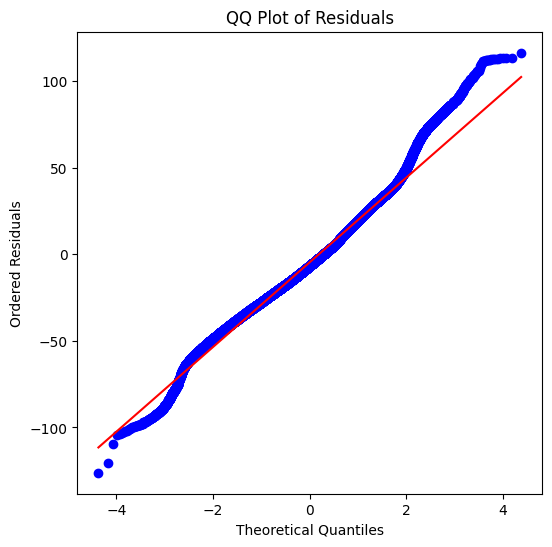

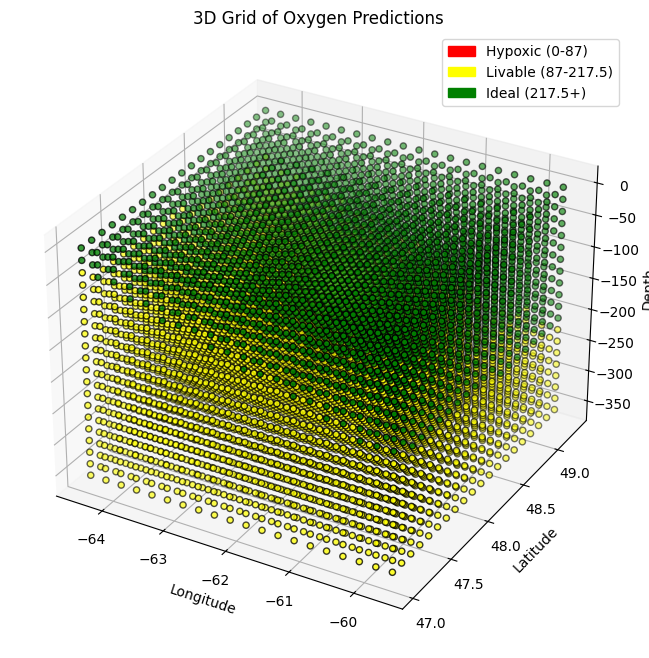

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from itertools import product
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler  # Added for standardization
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
import matplotlib.patches as mpatches

# Define target and columns to exclude
target = 'oxygen'
exclude_cols = [target, 'voxel']

# Hyperparameter grid for ElasticNet
param_grid = {
    'alpha': np.logspace(-3, 3, 10),       # penalty term
    'l1_ratio': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, .7, 0.8, 0.9, 1]    # elasticnet mixing parameter
}

# Convert grid to list of combinations
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print(f"Total combinations of parameters to try: {len(param_combinations)}")
fold_count = 10  # Number of folds

# Define a function to evaluate one combination of hyperparameters
def evaluate_params(params):
    mse_scores = []
    r2_scores = []

    # Loop over each fold
    for train_df, test_df in custom_folds[:fold_count]:
        X_train = train_df.drop(columns=exclude_cols)
        y_train = train_df[target]
        X_test = test_df.drop(columns=exclude_cols)
        y_test = test_df[target]

        # --- Begin Standardization per fold ---
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train)
        X_test_scaled = scaler_fold.transform(X_test)
        # --- End Standardization per fold ---

        model = ElasticNet(alpha=params['alpha'],
                           l1_ratio=params['l1_ratio'],
                           random_state=30)
        # Original code: model.fit(X_train, y_train)
        model.fit(X_train_scaled, y_train)
        # Original code: y_pred = model.predict(X_test)
        y_pred = model.predict(X_test_scaled)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mse_scores.append(mse)
        r2_scores.append(r2)
        print(f"Fold R²: {r2}")

    avg_mse = np.mean(mse_scores)
    avg_r2 = np.mean(r2_scores)
    print(f"Params: {params} → Avg MSE: {avg_mse:.4f} | Avg R²: {avg_r2:.4f}\n")
    return (params, avg_mse, avg_r2)

# Evaluate all hyperparameter combinations in parallel
results = Parallel(n_jobs=-1)(
    delayed(evaluate_params)(dict(zip(param_names, combo)))
    for combo in param_combinations
)

# Find best parameter set (using smallest MSE)
best_result = min(results, key=lambda x: x[1])
best_params, best_mse, best_r2 = best_result

print("\n===== Best Hyperparameters =====")
print(f"Best Params: {best_params}")
print(f"Avg MSE: {best_mse:.4f}")
print(f"Avg R²: {best_r2:.4f}")
print(f"Best RMSE: {np.sqrt(best_mse):.4f}")

# Train final model on the full training data and evaluate on unseen test data
train_df = pd.concat([training_datasets[i] for i in range(len(training_datasets))], ignore_index=True)
test_df = pd.concat([testing_datasets[i] for i in range(len(testing_datasets))], ignore_index=True)

X_train = train_df.drop(columns=exclude_cols)
y_train = train_df[target]
X_test = test_df.drop(columns=exclude_cols)
y_test = test_df[target]

# --- Begin Standardization for final model ---
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)
# --- End Standardization for final model ---

final_model = ElasticNet(alpha=best_params['alpha'],
                         l1_ratio=best_params['l1_ratio'],
                         random_state=30)
# Original code: final_model.fit(X_train, y_train)
final_model.fit(X_train_scaled, y_train)
# Original code: y_pred = final_model.predict(X_test)
y_pred = final_model.predict(X_test_scaled)

final_mse = mean_squared_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)

print(f"R² for Final Model: {final_r2}")
print(f"MSE for Final Model: {final_mse}")

# --- Additional Code Below: Coefficients, QQ Plot, and 3D Grid Predictions ---

# 1. Print the regression coefficients
coefficients = final_model.coef_
intercept = final_model.intercept_
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(X_train.columns, coefficients):
    print(f"  {feature}: {coef}")

# 2. Create a QQ plot for the residuals
residuals = y_test - y_pred
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Residuals")
plt.show()

# 3. Create a 3D grid over (longitude, latitude, depth) and predict oxygen
grid_res = 20  # Grid resolution: number of points per axis

# Determine ranges for spatial coordinates from training data
lon_min, lon_max = X_train['longitude'].min(), X_train['longitude'].max()
lat_min, lat_max = X_train['latitude'].min(), X_train['latitude'].max()
depth_min, depth_max = X_train['depth'].min(), X_train['depth'].max()

lon_grid = np.linspace(lon_min, lon_max, grid_res)
lat_grid = np.linspace(lat_min, lat_max, grid_res)
depth_grid = np.linspace(depth_min, depth_max, grid_res)

lon_mesh, lat_mesh, depth_mesh = np.meshgrid(lon_grid, lat_grid, depth_grid)
grid_points = np.column_stack((lon_mesh.ravel(), lat_mesh.ravel(), depth_mesh.ravel()))

# Create a DataFrame for the grid (with spatial columns)
grid_df = pd.DataFrame(grid_points, columns=['longitude', 'latitude', 'depth'])

# For other predictors, set their values to the mean from the training data
other_features = [col for col in X_train.columns if col not in ['longitude', 'latitude', 'depth']]
for col in other_features:
    grid_df[col] = X_train[col].mean()

# Reorder columns to match the original training data
grid_df = grid_df[X_train.columns]

# Standardize grid predictors using the same final scaler
grid_scaled = scaler_final.transform(grid_df)

# Predict oxygen on each grid point
grid_predictions = final_model.predict(grid_scaled)
grid_df['oxygen_pred'] = grid_predictions

# Define a function to assign a color based on oxygen prediction thresholds
def get_color(oxygen):
    if oxygen < 87:
        return 'red'      # Hypoxic
    elif oxygen < 217.5:
        return 'yellow'   # Livable
    else:
        return 'green'    # Ideal

grid_df['color'] = grid_df['oxygen_pred'].apply(get_color)

# Plot the predictions on the 3D grid
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(grid_df['longitude'], grid_df['latitude'], -grid_df['depth'],
                     c=grid_df['color'], s=20, edgecolor='k')

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth")
ax.set_title("3D Grid of Oxygen Predictions")

# Create a custom legend for the color thresholds
legend_elements = [
    mpatches.Patch(color='red', label='Hypoxic (0-87)'),
    mpatches.Patch(color='yellow', label='Livable (87-217.5)'),
    mpatches.Patch(color='green', label='Ideal (217.5+)')
]
ax.legend(handles=legend_elements, loc='best')

plt.show()


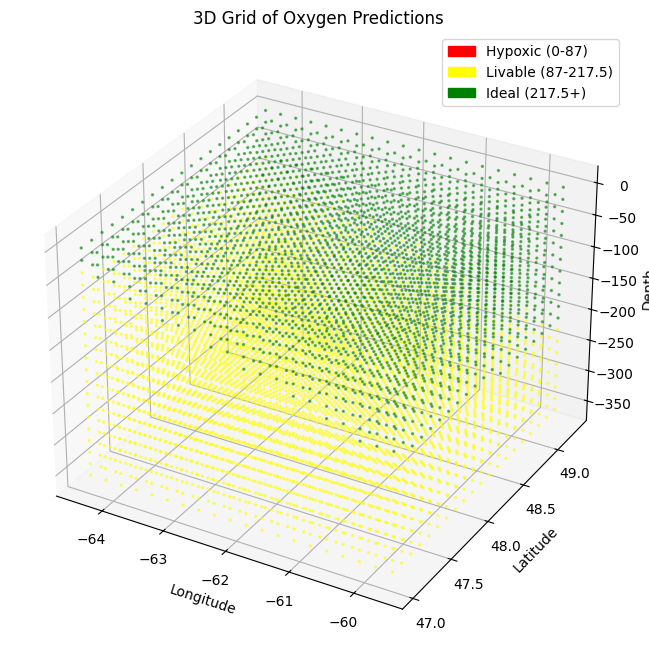

In [ ]:

# Plot the predictions on the 3D grid
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(grid_df['longitude'], grid_df['latitude'], -grid_df['depth'],
                     c=grid_df['color'], alpha = 0.5, s=2)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth")
ax.set_title("3D Grid of Oxygen Predictions")

# Create a custom legend for the color thresholds
legend_elements = [
    mpatches.Patch(color='red', label='Hypoxic (0-87)'),
    mpatches.Patch(color='yellow', label='Livable (87-217.5)'),
    mpatches.Patch(color='green', label='Ideal (217.5+)')
]
ax.legend(handles=legend_elements, loc='best')

plt.show()

Intercept: 223.54207
Coefficients:
  longitude: 14.675506591796875
  latitude: 2.491882085800171
  depth: -31.525012969970703
  salinity: -52.01642608642578
  density: -0.0
  temperature: -49.152530670166016


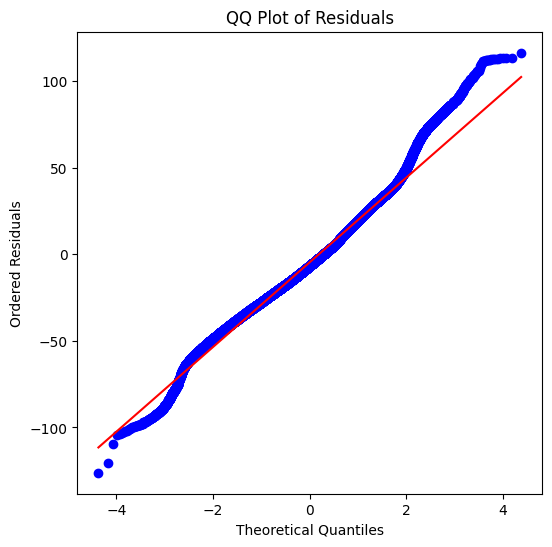

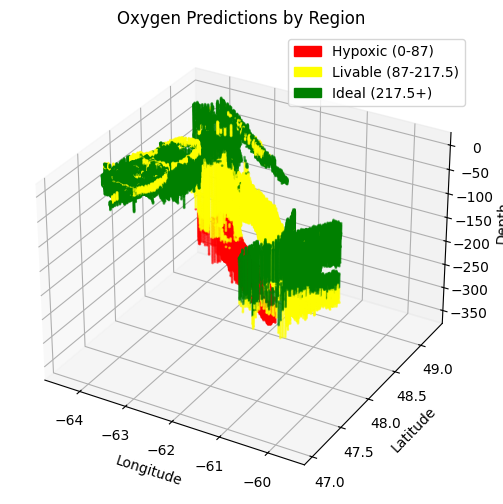

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting



# ---- 1. Print the regression coefficients ----
coefficients = final_model.coef_
intercept = final_model.intercept_
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(X_train.columns, coefficients):
    print(f"  {feature}: {coef}")

# ---- 2. Create a QQ plot for the residuals ----
# Calculate residuals from the final model predictions
residuals = y_test - y_pred

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Residuals")
plt.show()

# ---- 3. 3D Scatter Plot of Oxygen Predictions ----
# Assume that test_df contains columns 'longitude', 'latitude', and 'depth'
# Add predictions to the test dataframe
test_df = test_df.copy()  # avoid modifying original dataframe
test_df["oxygen_pred"] = y_pred

# Define a function to assign color based on oxygen prediction
def get_color(oxygen):
    if oxygen < 87:
        return 'red'      # Hypoxic
    elif oxygen < 217.5:
        return 'yellow'   # Livable
    else:
        return 'green'    # Ideal

# Apply the color function to each predicted oxygen value
test_df["color"] = test_df["oxygen_pred"].apply(get_color)

# Create a 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(test_df['longitude'], test_df['latitude'], -test_df['depth'],
                c=test_df['color'], s=1, alpha = 0.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth")
ax.set_title("Oxygen Predictions by Region")

# Optionally, create a custom legend
import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color='red', label='Hypoxic (0-87)'),
    mpatches.Patch(color='yellow', label='Livable (87-217.5)'),
    mpatches.Patch(color='green', label='Ideal (217.5+)')
]
ax.legend(handles=legend_elements, loc='best')

plt.show()


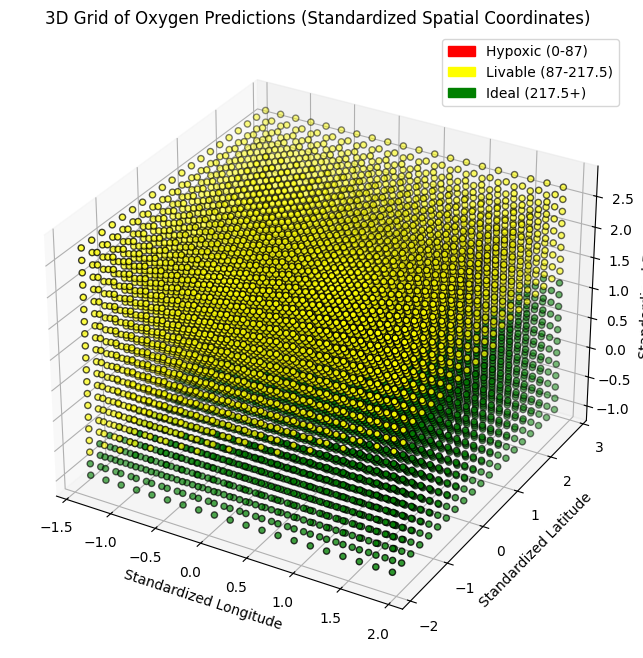

In [ ]:
# --- Additional Code Below: 3D Grid Predictions in Standardized Space ---

# 3. Create a 3D grid over (longitude, latitude, depth) and predict oxygen
grid_res = 20  # Grid resolution: number of points per axis

# Determine ranges for spatial coordinates from training data (original values)
lon_min, lon_max = X_train['longitude'].min(), X_train['longitude'].max()
lat_min, lat_max = X_train['latitude'].min(), X_train['latitude'].max()
depth_min, depth_max = X_train['depth'].min(), X_train['depth'].max()

lon_grid = np.linspace(lon_min, lon_max, grid_res)
lat_grid = np.linspace(lat_min, lat_max, grid_res)
depth_grid = np.linspace(depth_min, depth_max, grid_res)

lon_mesh, lat_mesh, depth_mesh = np.meshgrid(lon_grid, lat_grid, depth_grid)
grid_points = np.column_stack((lon_mesh.ravel(), lat_mesh.ravel(), depth_mesh.ravel()))

# Create a DataFrame for the grid using original (non-standardized) values for spatial predictors
grid_df = pd.DataFrame(grid_points, columns=['longitude', 'latitude', 'depth'])

# For the other predictors, set their values to the mean from the training data
other_features = [col for col in X_train.columns if col not in ['longitude', 'latitude', 'depth']]
for col in other_features:
    grid_df[col] = X_train[col].mean()

# Reorder columns to match the original training data
grid_df = grid_df[X_train.columns]

# Standardize the grid predictors using the same final scaler
grid_scaled = scaler_final.transform(grid_df)
grid_scaled_df = pd.DataFrame(grid_scaled, columns=X_train.columns)

# Predict oxygen on each grid point using the standardized grid
grid_predictions = final_model.predict(grid_scaled)
grid_scaled_df['oxygen_pred'] = grid_predictions

# Define a function to assign color based on oxygen prediction thresholds
def get_color(oxygen):
    if oxygen < 87:
        return 'red'      # Hypoxic
    elif oxygen < 217.5:
        return 'yellow'   # Livable
    else:
        return 'green'    # Ideal

grid_scaled_df['color'] = grid_scaled_df['oxygen_pred'].apply(get_color)

# Plot the predictions on the 3D grid in standardized space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(grid_scaled_df['longitude'], grid_scaled_df['latitude'], grid_scaled_df['depth'],
                     c=grid_scaled_df['color'], s=20, edgecolor='k')

ax.set_xlabel("Standardized Longitude")
ax.set_ylabel("Standardized Latitude")
ax.set_zlabel("Standardized Depth")
ax.set_title("3D Grid of Oxygen Predictions (Standardized Spatial Coordinates)")

# Create a custom legend for the color thresholds
legend_elements = [
    mpatches.Patch(color='red', label='Hypoxic (0-87)'),
    mpatches.Patch(color='yellow', label='Livable (87-217.5)'),
    mpatches.Patch(color='green', label='Ideal (217.5+)')
]
ax.legend(handles=legend_elements, loc='best')

plt.show()


In [5]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 MB 3.4 MB/s eta 0:00:00


In [8]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from itertools import product
from joblib import Parallel, delayed

target = 'oxygen'
exclude_cols = [target, 'voxel']

# Define your hyperparameter grid
param_grid = {
    #'n_estimators': [100],
    'learning_rate': np.linspace(0.01, 0.5, 100),
    'max_depth': [i for i in range(3, 9)],
    #'subsample': [0.8],
    #'colsample_bytree': [0.8]
}

# Convert grid to a list of parameter combinations
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print(f"Total combinations of parameters to try: {len(param_combinations)}")
fold_count = 10  # number of folds to use from custom_folds

def evaluate_params(params, folds):
    mse_scores = []
    r2_scores = []
    for train_df, test_df in folds:
        X_train = train_df.drop(columns=exclude_cols)
        y_train = train_df[target]
        X_test = test_df.drop(columns=exclude_cols)
        y_test = test_df[target]

        model = xgb.XGBRegressor(
            **params,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse_scores.append(mean_squared_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))
        print(f"R² for current fold: {r2_scores[-1]} with {len(folds)} folds")

    avg_mse = np.mean(mse_scores)
    avg_r2 = np.mean(r2_scores)
    print(f"Evaluated params {params}: Avg MSE = {avg_mse:.4f} | Avg R² = {avg_r2:.4f}")
    return (params, avg_mse, avg_r2)

# Parallelize evaluation over all parameter combinations
results = Parallel(n_jobs=-1)(
    delayed(evaluate_params)(
        dict(zip(param_names, combo)),
        custom_folds[:fold_count]
    )
    for combo in param_combinations
)

# Find best param set (using smallest average MSE)
best_result = min(results, key=lambda x: x[1])
best_params, best_mse, best_r2 = best_result

print("\n===== Best Hyperparameters =====")
print(f"Best Params: {best_params}")
print(f"Avg MSE: {best_mse:.4f}")
print(f"Avg R²: {best_r2:.4f}")
print(f"Best RMSE: {np.sqrt(best_mse):.4f}")

# Now, you can proceed to train your final model using best_params.


# Train final model on the full training data and evaluate on unseen test data
train_df = pd.concat([training_datasets[i] for i in range(len(training_datasets))], ignore_index=True)
test_df = pd.concat([testing_datasets[i] for i in range(len(testing_datasets))], ignore_index=True)

X_train = train_df.drop(columns=exclude_cols)
y_train = train_df[target]
X_test = test_df.drop(columns=exclude_cols)
y_test = test_df[target]

final_model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    verbosity=0
)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

final_mse = mean_squared_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)

print(f"R² for Final Model: {final_r2}")
print(f"MSE for Final Model: {final_mse}")

Total combinations of parameters to try: 600

===== Best Hyperparameters =====
Best Params: {'learning_rate': np.float64(0.08919191919191918), 'max_depth': 7}
Avg MSE: 237.1662
Avg R²: 0.9612
Best RMSE: 15.4002
R² for Final Model: 0.9618253111839294
MSE for Final Model: 274.7483825683594


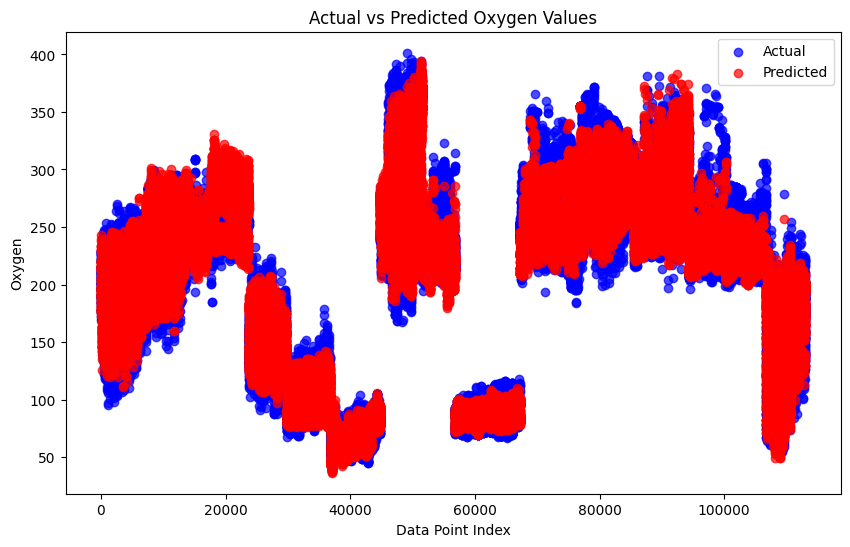

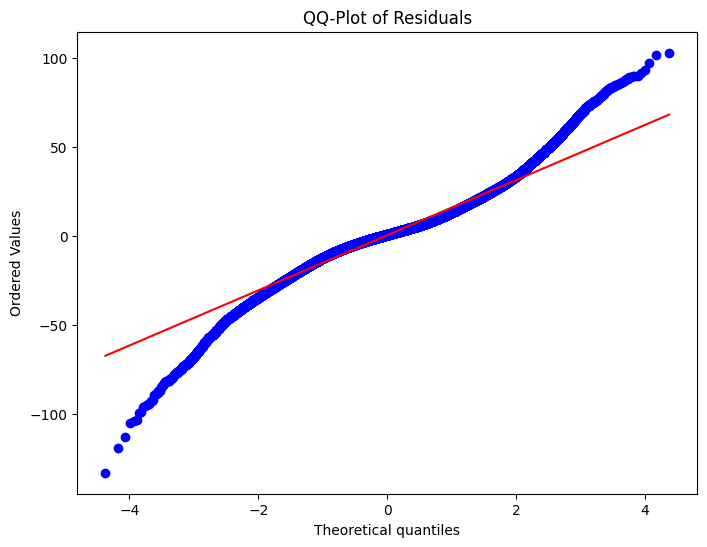

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb
import scipy.stats as stats

# ----- Plotting the Final Decision Tree -----


# ----- Plotting Predictions for Each Data Point -----
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', alpha=0.7)
plt.scatter(range(len(y_test)), y_pred, color='red', label='Predicted', alpha=0.7)
plt.xlabel('Data Point Index')
plt.ylabel('Oxygen')
plt.title('Actual vs Predicted Oxygen Values')
plt.legend()
plt.show()

# ----- QQ-Plot for Residuals -----
# Calculate residuals (difference between actual and predicted values)
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()


A Custom CV Fold Generator

In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Replace with the actual column name of your target
target_col = 'oxygen'  # example

mse_rf_scores = []
r2_rf_scores = []

for i, (train_df, test_df) in enumerate(custom_folds):
    X_train = train_df.drop(columns=[target_col,'voxel'])
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=[target_col,'voxel'])
    y_test = test_df[target_col]

    # Define and train Random Forest model
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    # Predictions
    y_pred = rf_model.predict(X_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_rf_scores.append(mse)
    r2_rf_scores.append(r2)

    print(f"[RF] Fold {i+1:03d} | MSE: {mse:.4f} | R²: {r2:.4f}")

# Final summary
print("\n===== Random Forest CV Results =====")
print(f"Average MSE: {np.mean(mse_rf_scores):.4f} ± {1.96*np.std(mse_rf_scores):.4f}")
print(f"Average R²: {np.mean(r2_rf_scores):.4f} ± {1.96*np.std(r2_rf_scores):.4f}")


In [9]:
# XGBoost displaying for each fold

import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from itertools import product

target = 'oxygen'
exclude_cols = [target, 'voxel']

# Define your hyperparameter grid
param_grid = {
    'n_estimators': [100],
    'learning_rate': np.linspace(0.01, 0.1, 10),
    #'learning_rate': [0.06],
    'max_depth': [8],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Convert to list of param combinations
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

# To store average CV scores for each param combo
results = []

print(f"Total combinations of parameters to try: {len(param_combinations)}")
fold_count = 10
for combo in param_combinations:
    params = dict(zip(param_names, combo))
    mse_scores = []
    r2_scores = []

    for train_df, test_df in custom_folds[:fold_count]:
        X_train = train_df.drop(columns=exclude_cols)
        y_train = train_df[target]
        X_test = test_df.drop(columns=exclude_cols)
        y_test = test_df[target]

        model = xgb.XGBRegressor(
            **params,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mse_scores.append(mse)
        r2_scores.append(r2)
        print(f"R² across current fold: {r2} with length {len(custom_folds[:fold_count])}")

    avg_mse = np.mean(mse_scores)
    avg_r2 = np.mean(r2_scores)
    results.append((params, avg_mse, avg_r2))

    print(f"Params: {params}")
    print(f"→ Avg MSE: {avg_mse:.4f} | Avg R²: {avg_r2:.4f}\n")

# Find best param set
best_result = min(results, key=lambda x: x[1])  # smallest MSE
best_params, best_mse, best_r2 = best_result

print("\n===== Best Hyperparameters =====")
print(f"Best Params: {best_params}")
print(f"Avg MSE: {best_mse:.4f}")
print(f"Avg R²: {best_r2:.4f}")
print(f"Best RMSE: {np.sqrt(best_mse):.4f}")


Total combinations of parameters to try: 10
R² across current fold: 0.806281566619873 with length 10
R² across current fold: 0.6889204978942871 with length 10
R² across current fold: 0.8089377880096436 with length 10
R² across current fold: 0.805697500705719 with length 10
R² across current fold: 0.7882822155952454 with length 10
R² across current fold: 0.8055717945098877 with length 10
R² across current fold: 0.6646468639373779 with length 10
R² across current fold: 0.8279016613960266 with length 10
R² across current fold: 0.7892176508903503 with length 10
R² across current fold: 0.8020617961883545 with length 10
Params: {'n_estimators': 100, 'learning_rate': np.float64(0.01), 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8}
→ Avg MSE: 1348.2401 | Avg R²: 0.7788

R² across current fold: 0.9365970492362976 with length 10


KeyboardInterrupt: 

<ipython-input-10-b23cdf24c932>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
<ipython-input-10-b23cdf24c932>:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Learning Rate')


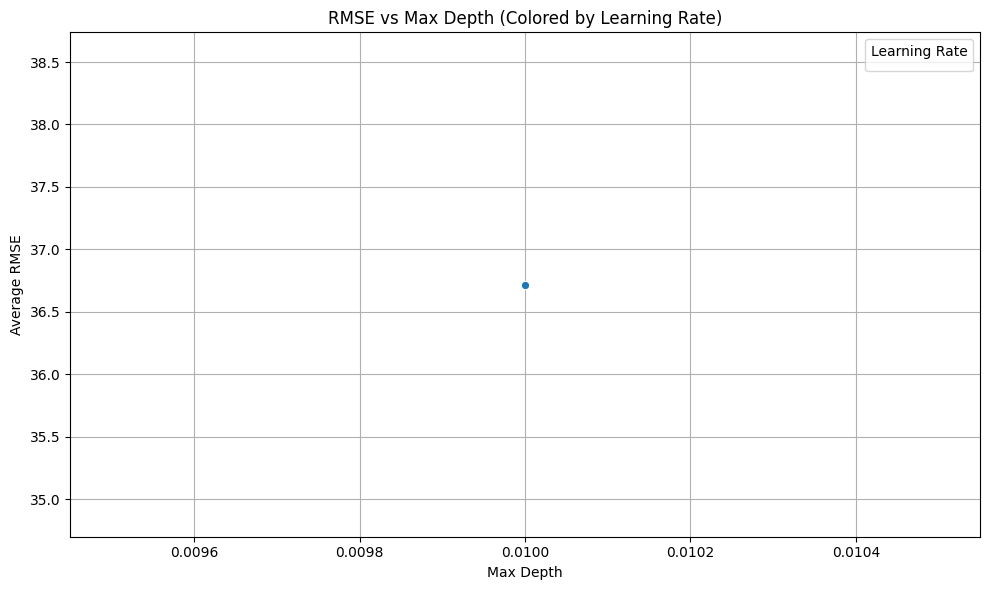

In [10]:
results_df = pd.DataFrame([
    {
        **params,
        'avg_mse': avg_mse,
        'avg_r2': avg_r2,
        'avg_rmse': np.sqrt(avg_mse)
    }
    for params, avg_mse, avg_r2 in results
])
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=results_df,
    x='learning_rate',
    y='avg_rmse',
    marker='o',
    palette='tab10'
)

plt.title("RMSE vs Max Depth (Colored by Learning Rate)")
plt.xlabel("Max Depth")
plt.ylabel("Average RMSE")
plt.grid(True)
plt.legend(title='Learning Rate')
plt.tight_layout()
plt.show()


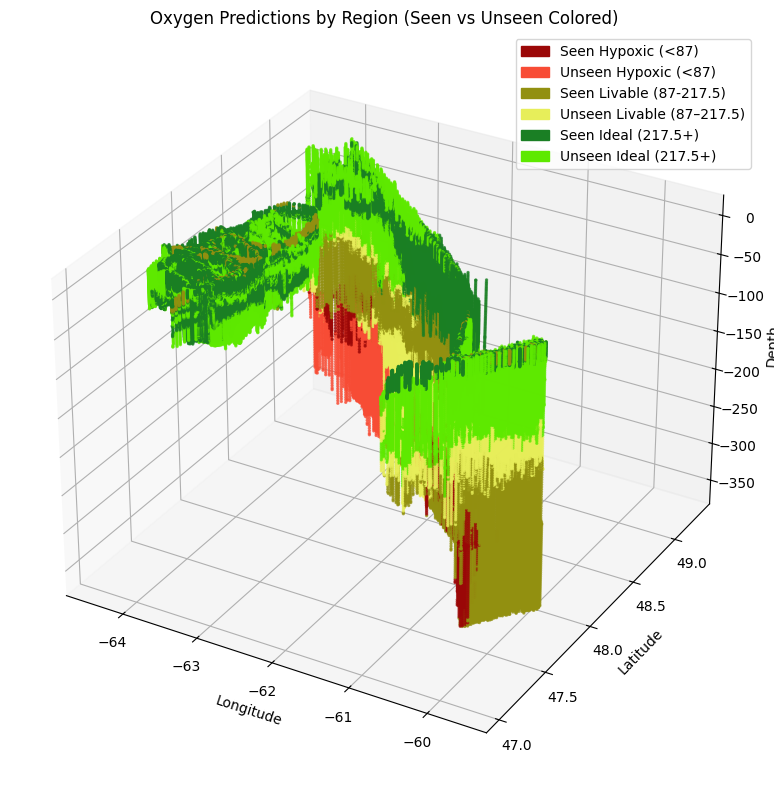

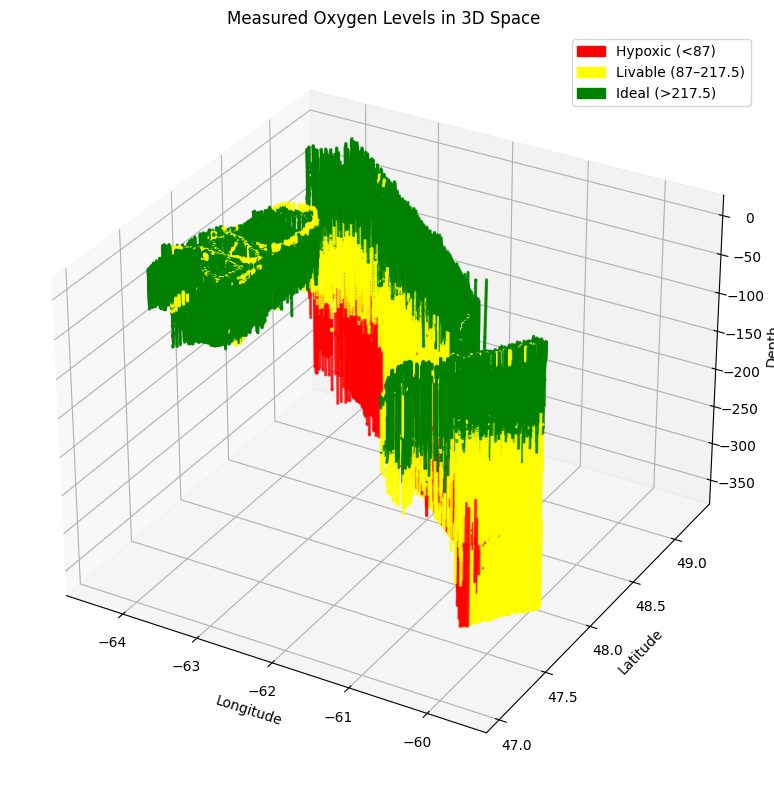

In [33]:
# Region plots on predicted data


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

# === Label each row as 'train' or 'test' ===
for df in training_datasets:
    df["source"] = "train"
for df in testing_datasets:
    df["source"] = "test"

# Combine all into one full dataset
full_df = pd.concat(training_datasets + testing_datasets, ignore_index=True)

# Prepare features/target
X_full = full_df.drop(columns=[target, 'voxel', 'source'])
y_full = full_df[target]

# Train the model
final_model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    verbosity=0
)
final_model.fit(X_full, y_full)

# Predict
y_pred = final_model.predict(X_full)
full_df = full_df.copy()
full_df["oxygen_pred"] = y_pred

# === Color Mapping Based on Prediction and Source ===
def get_color(row):
    oxygen = row["oxygen_pred"]
    source = row["source"]

    if oxygen < 87:
        return '#9b0707' if source == "train" else '#f84c35'  # Hypoxic - Red
    elif oxygen < 217.5:
        return '#929010' if source == "train" else '#e7ee5a'  # Livable - Yellow
    else:
        return '#1a7f24' if source == "train" else '#5ee900'  # Ideal - Green
full_df["color"] = full_df.apply(get_color, axis=1)

# === 3D Scatter Plot ===
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    full_df['longitude'],
    full_df['latitude'],
    -full_df['depth'],
    c=full_df['color'],
    s=2,
    alpha=0.7
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth")
ax.set_title("Oxygen Predictions by Region (Seen vs Unseen Colored)")

# Legend
legend_elements = [
    mpatches.Patch(color='#9b0707', label='Seen Hypoxic (<87)'), # dark red
    mpatches.Patch(color='#f84c35', label='Unseen Hypoxic (<87)'), # light red
    mpatches.Patch(color='#929010', label='Seen Livable (87-217.5)'), # dark yellow
    mpatches.Patch(color='#e7ee5a', label='Unseen Livable (87–217.5)'), # light yellow
    mpatches.Patch(color='#1a7f24', label='Seen Ideal (217.5+)'), # dark green
    mpatches.Patch(color='#5ee900', label='Unseen Ideal (217.5+)') # light green
]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()





###############################################################################

# Region plot on all data

# === Color Mapping Based Only on Oxygen Levels ===
def get_color_from_truth(oxygen):
    if oxygen < 87:
        return 'red'
    elif oxygen < 217.5:
        return 'yellow'
    else:
        return 'green'

full_df["color"] = full_df["oxygen"].apply(get_color_from_truth)

# === 3D Scatter Plot of True Oxygen ===
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    full_df['longitude'],
    full_df['latitude'],
    -full_df['depth'],
    c=full_df['color'],
    s=2,
    alpha=0.7
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth")
ax.set_title("Measured Oxygen Levels in 3D Space")

# Legend for true oxygen categories
legend_elements = [
    mpatches.Patch(color='red', label='Hypoxic (<87)'), # red
    mpatches.Patch(color='yellow', label='Livable (87–217.5)'), # yellow
    mpatches.Patch(color='green', label='Ideal (>217.5)') # green
]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()